In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
tickers_yahoo = ["AIR.PA", "HO.PA", "ML.PA", "ASML.AS", "REP.MC"]
start = "2025-01-01"
end   = "2026-02-17"
data = yf.download(tickers_yahoo, start=start, end=end)

[*********************100%***********************]  5 of 5 completed


In [16]:
prices = data["Close"].dropna(how="all", axis =1)
rets = prices.pct_change().dropna(how="all")

In [17]:
corr = rets.corr()
print("Tickers downloaded:", list(prices.columns))
corr.round(3)

Tickers downloaded: ['AIR.PA', 'ASML.AS', 'HO.PA', 'ML.PA', 'REP.MC']


Ticker,AIR.PA,ASML.AS,HO.PA,ML.PA,REP.MC
Ticker,,,,,
AIR.PA,1.000,0.373,0.469,0.276,0.215
ASML.AS,0.373,1.000,0.099,0.217,0.181
HO.PA,0.469,0.099,1.000,0.010,0.036
ML.PA,0.276,0.217,0.010,1.000,0.127
REP.MC,0.215,0.181,0.036,0.127,1.000


In [18]:
weekly_prices = prices.resample("W-FRI").last()
weekly_rets = weekly_prices.pct_change().dropna()
weekly_rets.corr().round(3)

Ticker,AIR.PA,ASML.AS,HO.PA,ML.PA,REP.MC
Ticker,,,,,
AIR.PA,1.000,0.375,0.294,0.484,0.324
ASML.AS,0.375,1.000,0.105,0.239,0.231
HO.PA,0.294,0.105,1.000,0.269,-0.000
ML.PA,0.484,0.239,0.269,1.000,0.361
REP.MC,0.324,0.231,-0.000,0.361,1.000


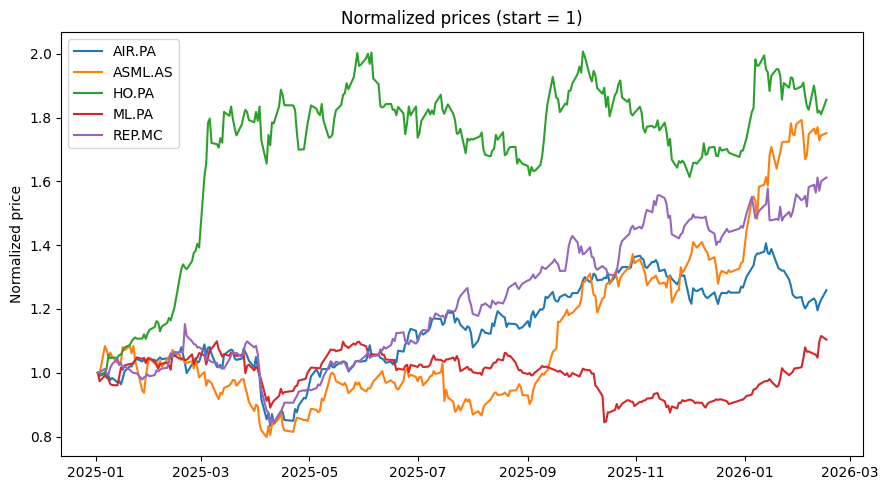

In [20]:
norm = prices / prices.iloc[0]  # start at 1
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(norm.index, norm.values)
ax.set_title("Normalized prices (start = 1)")
ax.set_ylabel("Normalized price")
ax.legend(norm.columns, loc="upper left")
plt.tight_layout()
plt.show()

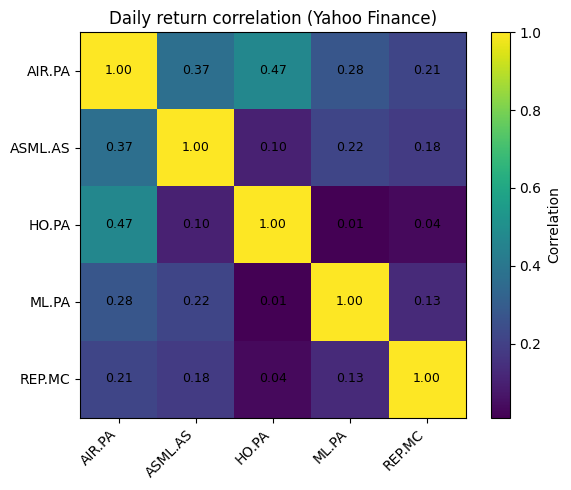

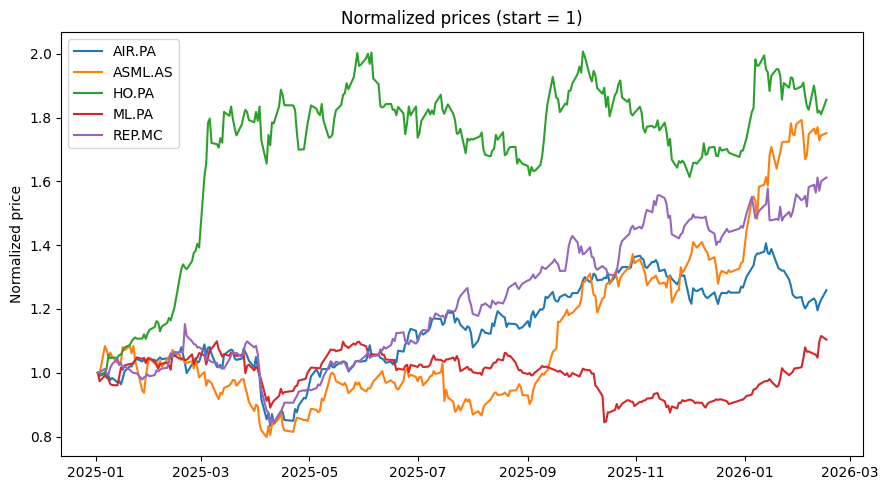

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values)  # default colormap

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

# annotate numbers
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Daily return correlation (Yahoo Finance)")
plt.tight_layout()
plt.show()

# =========================
# 2) Normalized PRICE PLOT
# =========================
norm = prices / prices.iloc[0]  # start at 1
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(norm.index, norm.values)
ax.set_title("Normalized prices (start = 1)")
ax.set_ylabel("Normalized price")
ax.legend(norm.columns, loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
weekly_prices = prices.resample("W-FRI").last()
weekly_rets = weekly_prices.pct_change().dropna()
weekly_corr = weekly_rets.corr()
weekly_corr

Ticker,AIR.PA,ASML.AS,HO.PA,ML.PA,REP.MC
Ticker,,,,,
AIR.PA,1.000000,0.374516,0.293704,0.483625,0.323958
ASML.AS,0.374516,1.000000,0.105092,0.239011,0.230796
HO.PA,0.293704,0.105092,1.000000,0.269380,-0.000466
ML.PA,0.483625,0.239011,0.269380,1.000000,0.361060
REP.MC,0.323958,0.230796,-0.000466,0.361060,1.000000
